# 🤖 N-BEATS Training v3 — Multi-country Electricity Forecasting

**Mục tiêu:** Train mô hình **N-BEATS** trên bộ dữ liệu đa quốc gia  
và lưu weights để làm **pretrained model** cho bước Transfer Learning sang Việt Nam.

---
| Mục | Thông tin |
|---|---|
| Dataset | `tft_premodel_dataset_EDA.csv` (34,614 rows × 30 cols) |
| Entities | 20 quốc gia |
| Series target | Coal, Gas, Hydro, Solar, Wind, Bioenergy, Nuclear, Other Fossil, Other Renewables |
| Encoder length | 24 tháng |
| Prediction length | 6 tháng |
| Model output | `checkpoint/nbeats_v3_best.ckpt` |

> **Lưu ý kiến trúc N-BEATS:**  
> N-BEATS là mô hình pure time-series (không dùng covariates như TFT).  
> Pipeline data giữ nguyên, nhưng model chỉ nhận `encoder_cont` (target + lags).  
> `time_varying_known_reals` và `static_categoricals` vẫn định nghĩa để dataset tương thích nhưng N-BEATS không dùng.

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & DEVICE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os, json, copy, shutil
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, NBeats
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import SMAPE

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ PyTorch  : {torch.__version__}')
print(f'   Device   : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')
print(f'   Lightning : {pl.__version__}')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR = Path(r'C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting')
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'tft_premodel_dataset_EDA.csv'
CKPT_DIR  = BASE_DIR / 'checkpoint'
LOG_DIR   = BASE_DIR / 'lightning_logs' / 'nbeats_v3'
CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f'   Data      : {DATA_PATH}')
print(f'   Checkpoint: {CKPT_DIR}')

✅ PyTorch  : 2.5.1+cu121
   Device   : cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)
   Lightning : 2.6.1
   Data      : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\data\processed\tft_premodel_dataset_EDA.csv
   Checkpoint: C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS & CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    # Dataset
    max_encoder_length    = 24,
    max_prediction_length = 6,
    min_series_length     = 30,
    val_cutoff_months     = 12,

    # N-BEATS interpretable architecture
    stack_types                     = ["trend", "seasonality"],
    num_blocks                      = [3, 3],
    num_block_layers                = [4, 4],
    widths                          = [256, 256],
    expansion_coefficient_lengths   = [3, 7],
    dropout                         = 0.1,

    # Training
    learning_rate         = 1e-3,
    batch_size            = 64,
    max_epochs            = 80,
    gradient_clip_val     = 0.1,
    patience              = 12,
    num_workers           = 0,

    # Seed
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('📋 Cấu hình N-BEATS:')
for k, v in CFG.items():
    print(f'   {k:<32}: {v}')

Seed set to 42


📋 Cấu hình N-BEATS:
   max_encoder_length              : 24
   max_prediction_length           : 6
   min_series_length               : 30
   val_cutoff_months               : 12
   stack_types                     : ['trend', 'seasonality']
   num_blocks                      : [3, 3]
   num_block_layers                : [4, 4]
   widths                          : [256, 256]
   expansion_coefficient_lengths   : [3, 7]
   dropout                         : 0.1
   learning_rate                   : 0.001
   batch_size                      : 64
   max_epochs                      : 80
   gradient_clip_val               : 0.1
   patience                        : 12
   num_workers                     : 0
   seed                            : 42


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & PREPROCESS DATA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_raw = pd.read_csv(DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f'Raw shape: {df_raw.shape}')

TARGET_SERIES = [
    'Coal', 'Gas', 'Hydro', 'Solar', 'Wind',
    'Bioenergy', 'Nuclear', 'Other Fossil', 'Other Renewables',
]
df = df_raw[df_raw['series'].isin(TARGET_SERIES)].copy()

# Giữ chuỗi đủ dài để đảm bảo tạo được encoder + prediction windows
counts = df.groupby(['entity', 'series']).size()
valid = counts[counts >= CFG['min_series_length']].reset_index()[['entity', 'series']]
df = df.merge(valid, on=['entity', 'series'])

# Tạo time_idx liên tục theo từng group
# N-BEATS dùng target history, nên chỉ cần date order chuẩn cho mỗi series.
df = df.sort_values(['entity', 'series', 'date'])
df['time_idx'] = df.groupby(['entity', 'series'])['date'].rank(method='dense').astype(int) - 1

# Xử lý missing target nếu có
df['generation_TWh'] = df.groupby(['entity', 'series'])['generation_TWh'].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

print(f'✅ Preprocessing done. Shape: {df.shape}')
print(f'   Groups: {df.groupby(["entity", "series"]).ngroups}')
print(f'   Missing generation_TWh: {df["generation_TWh"].isna().sum()}')

Raw shape: (34614, 30)
✅ Preprocessing done. Shape: (13859, 30)
   Groups: 151
   Missing generation_TWh: 0


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — TRAIN / VALIDATION SPLIT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])

print(f'📅 Train/Val Split:')
print(f'   training_cutoff (time_idx) : {training_cutoff}')
print(f'   val_cutoff_date            : {val_cutoff_date.date()}')
print(f'   Train rows                 : {(df["time_idx"] <= training_cutoff).sum():,}')
print(f'   Val rows                   : {(df["time_idx"] >  training_cutoff).sum():,}')

📅 Train/Val Split:
   training_cutoff (time_idx) : 83
   val_cutoff_date            : 2024-12-01
   Train rows                 : 12,451
   Val rows                   : 1,408


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — TimeSeriesDataSet cho N-BEATS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# N-BEATS trong pytorch-forecasting là univariate model:
# chỉ dùng target history, không dùng covariates.
print('⏳ Đang tạo TimeSeriesDataSet cho N-BEATS...')
training = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=CFG['max_encoder_length'],
    max_encoder_length=CFG['max_encoder_length'],
    min_prediction_length=CFG['max_prediction_length'],
    max_prediction_length=CFG['max_prediction_length'],
    static_categoricals=[],
    static_reals=[],
    time_varying_known_categoricals=[],
    time_varying_known_reals=[],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=['generation_TWh'],
    target_normalizer=GroupNormalizer(
        groups=['entity', 'series'],
        transformation='softplus',
    ),
    add_relative_time_idx=False,
    add_target_scales=False,
    add_encoder_length=False,
    allow_missing_timesteps=True,
    randomize_length=None,
)

validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)

print(f'✅ Training dataset  : {len(training):,} samples')
print(f'✅ Validation dataset: {len(validation):,} samples')

⏳ Đang tạo TimeSeriesDataSet cho N-BEATS...
✅ Training dataset  : 8,072 samples
✅ Validation dataset: 151 samples


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — DATALOADERS + SANITY CHECK
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_loader = training.to_dataloader(
    train      = True,
    batch_size = CFG['batch_size'],
    num_workers= CFG['num_workers'],
)
val_loader = validation.to_dataloader(
    train      = False,
    batch_size = CFG['batch_size'] * 2,
    num_workers= CFG['num_workers'],
)

x, y = next(iter(train_loader))
print('✅ DataLoaders sẵn sàng')
print(f'   Encoder shape : {x["encoder_cont"].shape}   (batch, time, features)')
print(f'   Target shape  : {y[0].shape}')
print(f'   Train batches : {len(train_loader)} batch/epoch')
print(f'   Val   batches : {len(val_loader)} batch/epoch')

✅ DataLoaders sẵn sàng
   Encoder shape : torch.Size([64, 24, 1])   (batch, time, features)
   Target shape  : torch.Size([64, 6])
   Train batches : 126 batch/epoch
   Val   batches : 2 batch/epoch


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — BUILD N-BEATS MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = NBeats.from_dataset(
    training,
    stack_types=CFG['stack_types'],
    num_blocks=CFG['num_blocks'],
    num_block_layers=CFG['num_block_layers'],
    widths=CFG['widths'],
    expansion_coefficient_lengths=CFG['expansion_coefficient_lengths'],
    dropout=CFG['dropout'],
    loss=SMAPE(),
    learning_rate=CFG['learning_rate'],
    optimizer='adam',
    log_interval=10,
    log_val_interval=1,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ N-BEATS Model built')
print(f'   Optimizer       : Adam')
print(f'   Parameters      : {n_params:,} ({n_params/1e6:.2f}M)')
print(f'   Stack types     : {CFG["stack_types"]}')
print(f'   Num blocks      : {CFG["num_blocks"]}')
print(f'   Block FC layers : {CFG["num_block_layers"]}')
print(f'   Block widths    : {CFG["widths"]}')
print(f'   Loss            : SMAPE')

✅ N-BEATS Model built
   Optimizer       : Adam
   Parameters      : 1,229,568 (1.23M)
   Stack types     : ['trend', 'seasonality']
   Num blocks      : [3, 3]
   Block FC layers : [4, 4]
   Block widths    : [256, 256]
   Loss            : SMAPE


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — CALLBACKS & TRAINER
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
checkpoint_callback = ModelCheckpoint(
    dirpath      = str(CKPT_DIR),
    filename     = 'nbeats_v3_{epoch:02d}_{val_loss:.4f}',
    monitor      = 'val_loss',
    mode         = 'min',
    save_top_k   = 3,
    save_last    = True,
    verbose      = True,
)

early_stop_callback = EarlyStopping(
    monitor   = 'val_loss',
    patience  = CFG['patience'],
    min_delta = 1e-4,
    mode      = 'min',
    verbose   = True,
)

lr_monitor = LearningRateMonitor(logging_interval='epoch')

logger = TensorBoardLogger(
    save_dir = str(BASE_DIR / 'lightning_logs'),
    name     = 'nbeats_v3',
    version  = 'run_1',
)

trainer = pl.Trainer(
    accelerator          = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices              = 1,
    max_epochs           = CFG['max_epochs'],
    gradient_clip_val    = CFG['gradient_clip_val'],
    callbacks            = [checkpoint_callback, early_stop_callback, lr_monitor],
    logger               = logger,
    enable_progress_bar  = True,
    enable_model_summary = True,
    log_every_n_steps    = 5,
    precision            = '16-mixed' if DEVICE == 'cuda' else '32',
)

print('✅ Trainer sẵn sàng')
print(f'   Max epochs      : {CFG["max_epochs"]}')
print(f'   EarlyStopping   : patience = {CFG["patience"]} epochs')
print(f'   Gradient clip   : {CFG["gradient_clip_val"]}')
print(f'   Checkpoint dir  : {CKPT_DIR}')

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Trainer sẵn sàng
   Max epochs      : 80
   EarlyStopping   : patience = 12 epochs
   Gradient clip   : 0.1
   Checkpoint dir  : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — TRAINING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🚀 Bắt đầu training N-BEATS...')
print('=' * 65)

trainer.fit(
    model,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

print('\n' + '=' * 65)
print('✅ Training hoàn tất!')
print(f'   Best val_loss   : {checkpoint_callback.best_model_score:.6f}')
print(f'   Best checkpoint : {checkpoint_callback.best_model_path}')
print(f'   Dừng tại epoch  : {trainer.current_epoch}')

🚀 Bắt đầu training N-BEATS...


You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ SMAPE      │      0 │ train │     0 │
│ 1 │ logging_metrics │ ModuleList │      0 │ train │     0 │
│ 2 │ net_blocks      │ ModuleList │  1.2 M │ train │     0 │
└───┴─────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 110                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Epoch 26, global step 3402: 'val_loss' was not in top 3


Epoch 27, global step 3528: 'val_loss' was not in top 3


Epoch 28, global step 3654: 'val_loss' was not in top 3


Monitored metric val_loss did not improve in the last 12 records. Best score: 0.232. Signaling Trainer to stop.
Epoch 29, global step 3780: 'val_loss' was not in top 3



✅ Training hoàn tất!
   Best val_loss   : 0.232126
   Best checkpoint : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\nbeats_v3_epoch=17_val_loss=0.2321-v1.ckpt
   Dừng tại epoch  : 30


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — LƯU CHECKPOINT & CONFIG JSON
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BEST_CKPT   = CKPT_DIR / 'nbeats_v3_best.ckpt'
LATEST_CKPT = CKPT_DIR / 'nbeats_v3_latest.ckpt'

best_src = checkpoint_callback.best_model_path
last_src = checkpoint_callback.last_model_path

if os.path.exists(best_src):
    shutil.copy2(best_src, BEST_CKPT)
    print(f'✅ Best checkpoint  → {BEST_CKPT}')

if os.path.exists(last_src):
    shutil.copy2(last_src, LATEST_CKPT)
    print(f'✅ Latest checkpoint → {LATEST_CKPT}')

# ── Lưu config JSON ────────────────────────────────────────────────────────────
model_config = {
    'version'                   : 'nbeats_v3',
    'best_ckpt'                 : str(BEST_CKPT),
    'best_val_loss'             : float(checkpoint_callback.best_model_score),
    'stopped_epoch'             : trainer.current_epoch,
    'max_encoder_length'        : CFG['max_encoder_length'],
    'max_prediction_length'     : CFG['max_prediction_length'],
    'target'                    : 'generation_TWh',
    'group_ids'                 : ['entity', 'series'],
    'target_normalizer'         : 'GroupNormalizer(softplus, groups=[entity,series])',
    'stack_types'               : CFG['stack_types'],
    'num_blocks'                : CFG['num_blocks'],
    'num_block_layers'          : CFG['num_block_layers'],
    'widths'                    : CFG['widths'],
    'expansion_coefficient_lengths': CFG['expansion_coefficient_lengths'],
    'dropout'                   : CFG['dropout'],
    'loss'                      : 'SMAPE',
    'optimizer'                 : 'adam',
    'train_entities'            : sorted(df['entity'].unique().tolist()),
    'train_series'              : sorted(df['series'].unique().tolist()),
    'train_date_range'          : [str(df['date'].min().date()), str(df['date'].max().date())],
}

config_path = CKPT_DIR / 'nbeats_v3_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)

print(f'\n✅ Config saved → {config_path}')

✅ Best checkpoint  → C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\nbeats_v3_best.ckpt
✅ Latest checkpoint → C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\nbeats_v3_latest.ckpt

✅ Config saved → C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\nbeats_v3_config.json


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — LOAD BEST MODEL & TÍNH METRICS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_model = NBeats.load_from_checkpoint(str(BEST_CKPT))
best_model.eval()
print(f'✅ Best N-BEATS model loaded từ {BEST_CKPT.name}')

# Point forecast
point_preds = best_model.predict(
    val_loader, mode='prediction', return_x=True,
)
pred_vals, x_vals = point_preds.output, point_preds.x

# Tính metrics (giống hệt TFT)
actuals = torch.cat([y[0] for _, y in val_loader])
mae  = (actuals - pred_vals).abs().mean().item()
rmse = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape_val = (2 * (actuals - pred_vals).abs() /
             (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape = (actuals - pred_vals).abs().sum().item() / (actuals.abs().sum().item() + 1e-8) * 100
ss_res = ((actuals - pred_vals) ** 2).sum().item()
ss_tot = ((actuals - actuals.mean()) ** 2).sum().item()
r2 = 1.0 - (ss_res / (ss_tot + 1e-8))

print(f'\n📊 Validation Metrics — N-BEATS (Best Model):')
print(f'   MAE   : {mae:.4f} TWh')
print(f'   RMSE  : {rmse:.4f} TWh')
print(f'   R2    : {r2:.4f}')
print(f'   SMAPE : {smape_val:.2f}%')
print(f'   WAPE  : {wape:.2f}%')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ Best N-BEATS model loaded từ nbeats_v3_best.ckpt

📊 Validation Metrics — N-BEATS (Best Model):
   MAE   : 0.7066 TWh
   RMSE  : 1.2148 TWh
   R2    : 0.9740
   SMAPE : 23.21%
   WAPE  : 12.95%


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


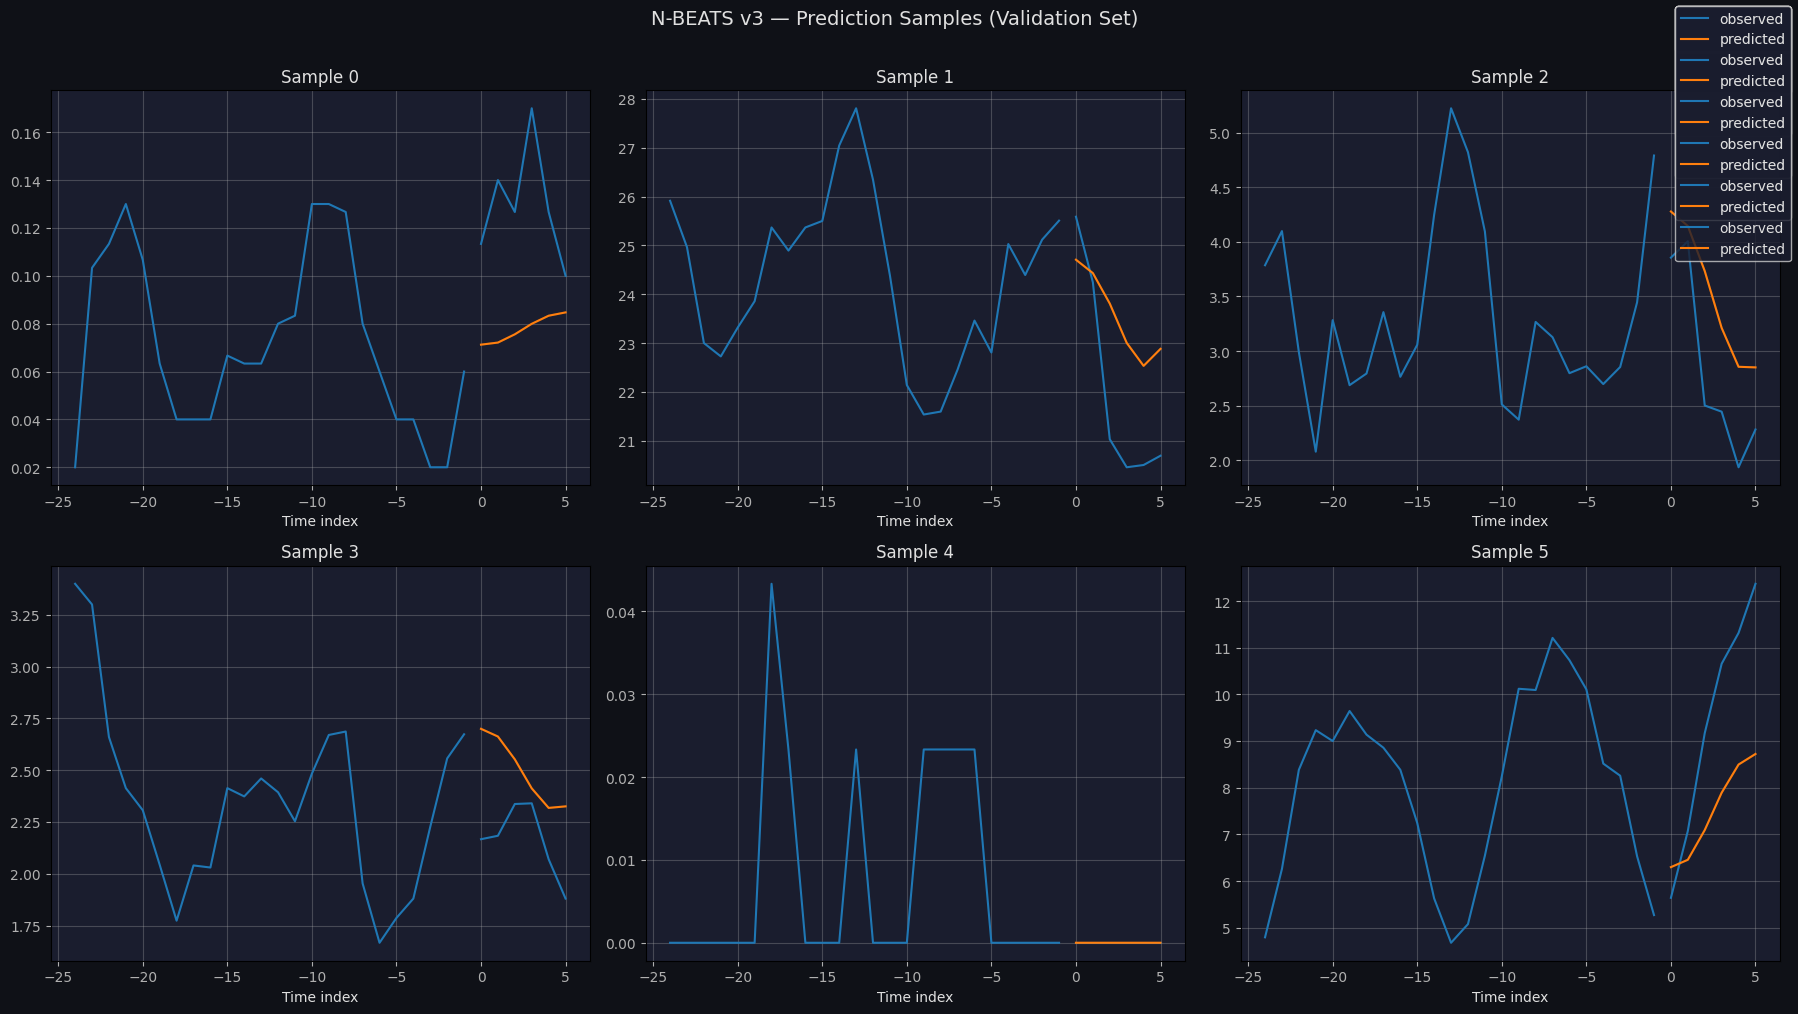

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — VISUALIZE PREDICTIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'text.color': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
})

# N-BEATS cũng hỗ trợ plot_prediction tương tự TFT
raw_preds = best_model.predict(val_loader, mode='raw', return_x=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, ax in enumerate(axes.flatten()):
    try:
        best_model.plot_prediction(
            raw_preds.x, raw_preds.output, idx=i, ax=ax,
        )
        ax.set_title(f'Sample {i}')
        ax.grid(alpha=0.3)
    except Exception:
        ax.set_visible(False)

plt.suptitle('N-BEATS v3 — Prediction Samples (Validation Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 — TRAINING LOSS CURVE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import glob
log_base = str(BASE_DIR / 'lightning_logs')
event_files = glob.glob(log_base + '/**/events.out*', recursive=True)

try:
    from tensorboard.backend.event_file_loader import EventFileLoader
    train_losses, val_losses = [], []
    for ef in event_files:
        loader = EventFileLoader(ef)
        for event in loader.Load():
            for v in event.summary.value:
                if v.tag == 'train_loss_epoch':
                    train_losses.append(v.simple_value)
                if v.tag == 'val_loss':
                    val_losses.append(v.simple_value)

    if train_losses or val_losses:
        fig, ax = plt.subplots(figsize=(13, 5))
        if train_losses:
            ax.plot(train_losses, label='Train Loss', color='#4fc3f7', linewidth=2)
        if val_losses:
            ax.plot(val_losses, label='Val Loss', color='#f06292', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('SMAPE Loss')
        ax.set_title('N-BEATS v3 — Training & Validation Loss Curve')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
except ImportError:
    pass

print(f'\n📊 Xem Training Curve đầy đủ trong TensorBoard:')
print(f'   tensorboard --logdir "{log_base}"')


📊 Xem Training Curve đầy đủ trong TensorBoard:
   tensorboard --logdir "C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\lightning_logs"


In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 — TỔNG KẾT & NEXT STEPS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('╔══════════════════════════════════════════════════════════════╗')
print('║              KẾT QUẢ TRAINING — N-BEATS v3                  ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Best val_loss : {checkpoint_callback.best_model_score:.6f}                        ║')
print(f'║  Epoch dừng   : {trainer.current_epoch}                                    ║')
print(f'║  MAE          : {mae:.4f} TWh                               ║')
print(f'║  RMSE         : {rmse:.4f} TWh                              ║')
print(f'║  R2           : {r2:.4f}                                  ║')
print(f'║  SMAPE        : {smape_val:.2f}%                                ║')
print(f'║  WAPE         : {wape:.2f}%                                 ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Best checkpoint : nbeats_v3_best.ckpt                      ║')
print(f'║  Config JSON     : nbeats_v3_config.json                    ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  NEXT STEPS — Transfer Learning sang VN:                     ║')
print('║  1. Dùng nbeats_v3_best.ckpt cho transfer_learning_nbeats   ║')
print('║  2. Copy weights tương thích sang VN model                   ║')
print('║  3. Fine-tune với LR = 1e-4 → 1e-5                          ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║              KẾT QUẢ TRAINING — N-BEATS v3                  ║
╠══════════════════════════════════════════════════════════════╣
║  Best val_loss : 0.232126                        ║
║  Epoch dừng   : 30                                    ║
║  MAE          : 0.7066 TWh                               ║
║  RMSE         : 1.2148 TWh                              ║
║  R2           : 0.9740                                  ║
║  SMAPE        : 23.21%                                ║
║  WAPE         : 12.95%                                 ║
╠══════════════════════════════════════════════════════════════╣
║  Best checkpoint : nbeats_v3_best.ckpt                      ║
║  Config JSON     : nbeats_v3_config.json                    ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEPS — Transfer Learning sang VN:                     ║
║  1. Dùng nbeats_v3_best.ckpt cho transfer_learning_nbeats   ║
║  2. Copy